## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 5 (Section 008 - Fall 2020)

The goal of this quiz is to give you the opportunity to test out some of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your new programming skills.

You are encouraged to look through the entire quiz before you get started so that you can appropriately budget your time and understand the broad goals of the exam.

The quiz is set up so that even if you get stuck on one question there are opportunities to get points on the other questions, so consider jumping ahead if you feel like you aren't making progress and then come back later if you have time.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

**Total points possible: 26**

---
## Academic integrity statement [1 point]

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size="+3">&#9998;</font> *Put your statement here*

---
## Writing Python code [25 points]

###ANSWER### (for making sure this gets removed)

**Note to instructors:** In this section, the goal provide students with the opportunity to showcase their ability to write code given what they should have had the opportunity to practice in the 5th homework assignment. Since they didn't end up getting a required Homework #5, I will be making it very clear to my students why they should be prepated to do. At any rate, this means that this question should ideally only involve the following new concepts:
* Solving a simple set of ODEs using `solve_ivp`
* Creating a compartmental model given a set of equations
* Visualizing the evolution of their compartmental model
* Answering conceptual questions based on the model results

For this quiz, I'm stepping away from trying to get the to pseudocode a solution first (as was used in the first two quizzes), since it's less clear how beneficial it would be for these questions. I may return to this style of questioning in the future.

&#9989;&nbsp; **Question 1 [15 points]**: As you might have heard in the news over the last few years, folks have been discovering that various water sources in Michigan have been contaminated with high levels of PFAS chemicals ([https://www.mlive.com/news/index.ssf/page/michigans_water_crisis_pfas.html](https://www.mlive.com/news/index.ssf/page/michigans_water_crisis_pfas.html)). Much of these chemicals are introduced by manufacturing companies improperly disposing of the by-products of the manufacturing process. 

If you consider the network of water sources in the state of Michigan (i.e. ponds, lakes, rivers, ground water), you might begin to understand how the introduction of a chemical into one location could lead an eventual contamination of the entire system -- eventually even our wonderful Lake Michigan could be impacted!

Let's take this scenario as our context for thinking about how one could build a compartmental model to study the movement of a pollutant a local pond system where a industrial factory might be dumping PFAS chemicals. Let's say that we have three ponds, $A$, $B$, and $C$, connected via streams in the following way, with the factory dumping pollutants at a rate of, $p$, into Pond $A$:

<div align="center"><img src="https://i.ibb.co/dW7VGLk/pond-model-001.png" width=300px></div>

we can then define a set of ordinary differential equations that describe how the pollutant moves through the system that might look something like this:

$$ \frac{dA}{dt} = p - qA + sC $$

$$ \frac{dB}{dt} = qA - rB $$

$$ \frac{dC}{dt} = rB - sC $$

where $p$ is the rate at which the pollutant is dumped into Pond $A$ and $q$, $r$, and $s$ are the "per minute" pollutant flow rates out of Ponds $A$, $B$, and $C$, respectively. In this model, we're using $A$, $B$, and $C$ to represent how many pounds of pollutant are currently in the corresponding pond.

Solve this pond pollution system using `solve_ivp()` and assume that all of the ponds start with **zero** pollutant, so the initial conditions are:

* $A(0) = 0$
* $B(0) = 0$
* $C(0) = 0$

Assume that the pollutant is dumped into Pond $A$ at a rate, $p = 0.125$ lb/min. Let $q = r = s = 0.001$.

Run the model for 48 hours (make sure to convert this to minutes!) and use a timestep of $\Delta t = 1$ minute.

**Note**: the provided comments give a possible structure for you to use in building your code

In [ ]:
# Put your code here

# Import all necessary modules


# Define the function for the "derivative equations" (ODEs)


# Set your initial conditions


# Define your start time, stop time, and array of time values


# Define your model parameters


# Call solve_ivp, make sure to pass in all of the appropriate arguments!


# Unpack your solution so that you have a single variable for each curve



In [1]:
### ANSWER ###

# Import needed modules
from scipy.integrate import solve_ivp
import math
import numpy as np

# Define the derivatives function
def derivs(t, vals, p, q, r, s):
    A, B, C = vals
    dAdt = p - q*A + s*C 
    dBdt = q*A - r*B
    dCdt = r*B - s*C
    return dAdt, dBdt, dCdt

# Solve the system

# ICs
A0 = 0
B0 = 0
C0 = 0
ICs = [A0, B0, C0]

# time array
t_start = 0
t_end = 2880
t = np.arange(t_start, t_end, 1.0)

# Model parameters
p = 0.125
q, r, s = 0.001, 0.001, 0.001

# Call solve_ivp()
sol = solve_ivp(derivs, (t_start,t_end), ICs, t_eval=t, args=(p,q,r,s))

# Unpack the solution
A = sol.y[0,:]
B = sol.y[1,:]
C = sol.y[2,:]

In [12]:
### ANSWER ###

# Import needed modules
from scipy.integrate import solve_ivp
import math
import numpy as np

# Define the derivatives function
def derivs(t, vals, p, q, r, s):
    A, B, C = vals
    dAdt = p - q*A + s*C 
    dBdt = q*A - r*B
    dCdt = r*B - s*C
    return dAdt, dBdt, dCdt

# Solve the system

# ICs
A0 = 0
B0 = 0
C0 = 0
ICs = [A0, B0, C0]

# time array
t_start = 0
t_end = 2*60*24
t = np.arange(t_start, t_end, 1.0)

# Model parameters
p = 0.125
q, r, s = 0.001, 0.001, 0.001

# Call solve_ivp()
sol = solve_ivp(derivs, (t_start,t_end), ICs, t_eval=t, args=(p,q,r,s))

# Unpack the solution
A = sol.y[0,:]
B = sol.y[1,:]
C = sol.y[2,:]

&#9989;&nbsp; **Question 2 [8 points]**: Now that you have a solution to the model, make a single plot that displays the evolution of all three variables, A, B, and C as a function time. Each line should be a different color and your plot should contain a $x$-axis label, a $y$-axis label, and a legend.

[If you failed to get solution to the model using `solve_ivp()`, create a plot with three lines of your own creation (e.g. cos(t), line for t$^2$, line for $e^t$, etc.) for the same range in time.]

In [ ]:
### Put your code here


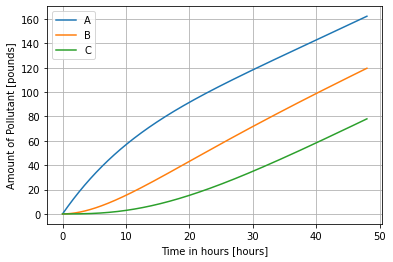

In [13]:
### ANSWER ###
# Import needed modules
import matplotlib.pyplot as plt
%matplotlib inline

divisor = 60
plt.figure(1)
plt.plot(t/divisor,A,label="A")
plt.plot(t/divisor,B,label="B")
plt.plot(t/divisor,C,label="C")
plt.xlabel("Time in hours [hours]")
plt.ylabel("Amount of Pollutant [pounds]")
plt.legend()
plt.grid()

&#9989;&nbsp; **Question 3 [2 points]**: You would like to get hard evidence that the polluters are dumping chemicals. However, you can only test samples from pond $C$, and you won’t be able to detect the pollutant unless there is at least 250 pounds (lbs) of it in the pond. If you test the pond 48 hours after the company started dumping, will you be able to detect the chemicals in pond $C$?

<font size=+3>&#9998;</font> *Put your answer here*

###ANSWER

They should comment that they are growing linearly (in a straight upward trend). This makes sense because the pollutant is being dumped in at a constant rate.

---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  Go to the "Quizzes" section, find the submission folder link for Quiz #5, and upload it there.

&#169; Copyright 2020,  Michigan State University Board of Trustees